# 2D Wind Visualization: Measured vs. Predicted

This notebook creates interactive and static 2D wind-vector visualizations from:

- `DJI_primary_standardized(1).csv`: the full standardized measured dataset
- `test_predictions(1).csv`: held-out measured values and model predictions
- `wind_model.joblib`: optional model artifact; **not required** to visualize the existing predictions

The notebook provides:

1. A measured-wind explorer for any flight in the full dataset.
2. Side-by-side measured-versus-predicted wind maps using identical spatial and vector scales.
3. Speed and direction comparisons along the flight sequence.
4. Per-flight error summaries and export options.

> **Direction convention:** The trained model metadata states that wind direction is meteorological **direction-from**, measured clockwise from north. The plotted arrows therefore point in the direction the air is moving. Set `DIRECTION_IS_FROM = False` below if a future dataset uses direction-toward instead.


In [4]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import plotly.graph_objects as go
    import plotly.figure_factory as ff
    from plotly.subplots import make_subplots
except ImportError as exc:
    raise ImportError(
        "Plotly is required. Install it with: %pip install plotly"
    ) from exc

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)


## 1. File paths and visualization settings


In [6]:
# Put this notebook in the same folder as the CSV files, or edit DATA_DIR.
DATA_DIR = Path(".")

ORIGINAL_CSV_NAME = "DJI_primary_standardized.csv"
PREDICTIONS_CSV_NAME = "test_predictions.csv"
MODEL_FILE_NAME = "wind_model.joblib"  # optional; not loaded by default

# Wind-direction convention:
# True  -> meteorological direction FROM, clockwise from north
# False -> direction TOWARD, clockwise from north
DIRECTION_IS_FROM = True

# Plot-density controls
MAX_ARROWS = 100
ARROW_LENGTH_FRACTION = 0.10
MIN_DIRECTION_SPEED_MPS = 0.5

def resolve_file(data_dir: Path, preferred_name: str, fallback_patterns=()):
    """Resolve a file robustly if the downloaded name changes slightly."""
    preferred = data_dir / preferred_name
    if preferred.exists():
        return preferred

    matches = []
    for pattern in fallback_patterns:
        matches.extend(sorted(data_dir.glob(pattern)))

    matches = list(dict.fromkeys(matches))
    if len(matches) == 1:
        warnings.warn(f"Using {matches[0].name!r} instead of {preferred_name!r}.")
        return matches[0]
    if len(matches) > 1:
        raise FileNotFoundError(
            f"Could not uniquely resolve {preferred_name!r}. Candidates: "
            + ", ".join(path.name for path in matches)
        )
    raise FileNotFoundError(
        f"Could not find {preferred_name!r} in {data_dir.resolve()}."
    )

ORIGINAL_CSV = resolve_file(
    DATA_DIR,
    ORIGINAL_CSV_NAME,
    ("DJI_primary_standardized*.csv", "*standardized*.csv"),
)
PREDICTIONS_CSV = resolve_file(
    DATA_DIR,
    PREDICTIONS_CSV_NAME,
    ("test_predictions*.csv", "*predictions*.csv"),
)
MODEL_FILE = DATA_DIR / MODEL_FILE_NAME

print("Original data:", ORIGINAL_CSV.resolve())
print("Predictions:  ", PREDICTIONS_CSV.resolve())
print("Model file:   ", MODEL_FILE.resolve(), "(optional)")


Original data: C:\Users\katel\BU-RISE\Project\3D-Wind_Visualization\DJI_primary_standardized.csv
Predictions:   C:\Users\katel\BU-RISE\Project\3D-Wind_Visualization\test_predictions.csv
Model file:    C:\Users\katel\BU-RISE\Project\3D-Wind_Visualization\wind_model.joblib (optional)


## 2. Load and check the data


In [7]:
original = pd.read_csv(ORIGINAL_CSV)
predictions = pd.read_csv(PREDICTIONS_CSV)

for frame in (original, predictions):
    if "Timestamp" in frame.columns:
        frame["Timestamp"] = pd.to_datetime(frame["Timestamp"], errors="coerce")

required_original = {
    "Flight_ID", "X", "Y", "Z", "Wind_speed", "Wind_angle"
}
required_predictions = required_original | {
    "Predicted_wind_speed", "Predicted_wind_angle"
}

missing_original = required_original - set(original.columns)
missing_predictions = required_predictions - set(predictions.columns)

if missing_original:
    raise ValueError(f"Original CSV is missing columns: {sorted(missing_original)}")
if missing_predictions:
    raise ValueError(
        f"Predictions CSV is missing columns: {sorted(missing_predictions)}"
    )

overview = pd.DataFrame(
    {
        "dataset": ["Full measured data", "Held-out predictions"],
        "rows": [len(original), len(predictions)],
        "flights": [
            original["Flight_ID"].nunique(),
            predictions["Flight_ID"].nunique(),
        ],
        "min_wind_mps": [
            original["Wind_speed"].min(),
            predictions["Wind_speed"].min(),
        ],
        "max_wind_mps": [
            original["Wind_speed"].max(),
            predictions["Wind_speed"].max(),
        ],
    }
)
display(overview)

print("\nPrediction columns:")
print(predictions.columns.tolist())


,dataset,rows,flights,min_wind_mps,max_wind_mps
0,Full measured data,257786,209,0.0,18.1
1,Held-out predictions,54548,42,0.0,18.1



Prediction columns:
['_Group_ID', 'Source_dataset', 'Flight_ID', 'Timestamp', 'Elapsed_s', 'X', 'Y', 'Z', 'Wind_speed', 'Wind_angle', 'Predicted_wind_speed', 'Predicted_wind_angle', 'Speed_error_mps', 'Angle_error_deg']


## 3. Coordinate and vector utilities

The standardized data uses longitude in `X` and latitude in `Y` for the DJI dataset. Plotting degree coordinates directly would distort vector geometry, so the helper below converts longitude/latitude to local east/north distances in meters using a small-area equirectangular approximation.

For meteorological direction-from angle \(\theta\):

\[
u_\mathrm{east} = -s\sin(\theta), \qquad
v_\mathrm{north} = -s\cos(\theta)
\]

where \(s\) is wind speed. This makes the arrows point **with the moving air**, rather than toward the direction from which the wind originated.


In [8]:
EARTH_RADIUS_M = 6_371_000.0

def infer_geographic_xy(df: pd.DataFrame) -> bool:
    """Return True when X/Y look like longitude/latitude."""
    xy = df[["X", "Y"]].dropna()
    if xy.empty:
        return False

    plausible = (
        xy["X"].between(-180, 180)
        & xy["Y"].between(-90, 90)
        & ~((xy["X"] == 0) & (xy["Y"] == 0))
    )
    return plausible.mean() >= 0.80


def add_local_xy(df: pd.DataFrame) -> tuple[pd.DataFrame, str]:
    """
    Add Plot_x_m and Plot_y_m.

    Geographic coordinates become local east/north meters. Local coordinates
    are translated around their medians.
    """
    out = df.copy().dropna(subset=["X", "Y"])
    geographic = infer_geographic_xy(out)

    if geographic:
        out = out.loc[~((out["X"] == 0) & (out["Y"] == 0))].copy()
        if out.empty:
            raise ValueError("No valid geographic positions remain after filtering.")

        lon0 = float(out["X"].median())
        lat0 = float(out["Y"].median())
        lat0_rad = np.deg2rad(lat0)

        out["Plot_x_m"] = (
            np.deg2rad(out["X"] - lon0)
            * EARTH_RADIUS_M
            * np.cos(lat0_rad)
        )
        out["Plot_y_m"] = (
            np.deg2rad(out["Y"] - lat0)
            * EARTH_RADIUS_M
        )
        coordinate_label = "Local east / north (m)"
    else:
        out["Plot_x_m"] = out["X"] - out["X"].median()
        out["Plot_y_m"] = out["Y"] - out["Y"].median()
        coordinate_label = "Local X / Y units"

    return out, coordinate_label


def wind_components(speed, angle_deg, direction_is_from: bool = True):
    """
    Convert speed and clockwise-from-north angle into east/north components.

    Returned vectors point in the direction the air moves.
    """
    speed = np.asarray(speed, dtype=float)
    theta = np.deg2rad(np.asarray(angle_deg, dtype=float))

    east = speed * np.sin(theta)
    north = speed * np.cos(theta)

    if direction_is_from:
        east = -east
        north = -north

    return east, north


def circular_difference_deg(predicted_deg, actual_deg):
    """Signed shortest angular difference in [-180, 180)."""
    predicted_deg = np.asarray(predicted_deg, dtype=float)
    actual_deg = np.asarray(actual_deg, dtype=float)
    return (predicted_deg - actual_deg + 180.0) % 360.0 - 180.0


def evenly_spaced_rows(df: pd.DataFrame, max_rows: int) -> pd.DataFrame:
    """Preserve flight order while selecting at most max_rows observations."""
    if len(df) <= max_rows:
        return df.copy()

    indices = np.linspace(0, len(df) - 1, max_rows)
    indices = np.unique(np.rint(indices).astype(int))
    return df.iloc[indices].copy()


def robust_vector_scale(
    x,
    y,
    speeds,
    arrow_length_fraction: float = ARROW_LENGTH_FRACTION,
):
    """Choose a common arrow multiplier based on map extent and wind speed."""
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    speeds = np.asarray(speeds, dtype=float)

    map_extent = max(
        float(np.nanmax(x) - np.nanmin(x)),
        float(np.nanmax(y) - np.nanmin(y)),
        1.0,
    )
    positive = speeds[np.isfinite(speeds) & (speeds > 0)]
    speed_reference = (
        float(np.nanpercentile(positive, 95)) if len(positive) else 1.0
    )

    return arrow_length_fraction * map_extent / max(speed_reference, 1e-9)


## 4. Interactive plotting functions


In [9]:
def _add_quiver_and_markers(
    fig,
    data: pd.DataFrame,
    speed_col: str,
    angle_col: str,
    row: int,
    col: int,
    trace_name: str,
    vector_scale: float,
    color_min: float,
    color_max: float,
    show_colorbar: bool,
):
    """Add trajectory, wind vectors, and speed-colored observation points."""
    east, north = wind_components(
        data[speed_col],
        data[angle_col],
        direction_is_from=DIRECTION_IS_FROM,
    )
    u = east * vector_scale
    v = north * vector_scale

    fig.add_trace(
        go.Scatter(
            x=data["Plot_x_m"],
            y=data["Plot_y_m"],
            mode="lines",
            name=f"{trace_name} path",
            line={"width": 1},
            hoverinfo="skip",
            showlegend=False,
        ),
        row=row,
        col=col,
    )

    qfig = ff.create_quiver(
        data["Plot_x_m"].to_numpy(),
        data["Plot_y_m"].to_numpy(),
        u,
        v,
        scale=1,
        arrow_scale=0.25,
        angle=np.pi / 8,
        name=trace_name,
    )
    qtrace = qfig.data[0]
    qtrace.update(
        name=f"{trace_name} vectors",
        line={"width": 1.4},
        hoverinfo="skip",
        showlegend=True,
    )
    fig.add_trace(qtrace, row=row, col=col)

    hover_data = np.column_stack(
        [
            data[speed_col].to_numpy(),
            data[angle_col].to_numpy(),
            (
                data["Z"].to_numpy()
                if "Z" in data.columns
                else np.full(len(data), np.nan)
            ),
        ]
    )
    fig.add_trace(
        go.Scatter(
            x=data["Plot_x_m"],
            y=data["Plot_y_m"],
            mode="markers",
            name=f"{trace_name} samples",
            marker={
                "size": 7,
                "color": data[speed_col],
                "cmin": color_min,
                "cmax": color_max,
                "showscale": show_colorbar,
                "colorbar": {"title": "Wind speed<br>(m/s)"},
            },
            customdata=hover_data,
            hovertemplate=(
                "East: %{x:.1f} m<br>"
                "North: %{y:.1f} m<br>"
                "Speed: %{customdata[0]:.2f} m/s<br>"
                "Direction from: %{customdata[1]:.1f}°<br>"
                "Altitude: %{customdata[2]:.1f} m"
                "<extra></extra>"
            ),
            showlegend=False,
        ),
        row=row,
        col=col,
    )


def plot_measured_flight(
    df: pd.DataFrame,
    flight_id,
    max_arrows: int = MAX_ARROWS,
):
    """Interactive 2D measured-wind map for one full-dataset flight."""
    flight = df.loc[df["Flight_ID"] == flight_id].copy()
    if flight.empty:
        raise ValueError(f"Flight_ID {flight_id!r} is not present in the dataset.")

    flight = flight.dropna(subset=["Wind_speed", "Wind_angle"])
    flight, _ = add_local_xy(flight)
    sampled = evenly_spaced_rows(flight, max_arrows)

    vector_scale = robust_vector_scale(
        sampled["Plot_x_m"],
        sampled["Plot_y_m"],
        sampled["Wind_speed"],
    )
    speed_max = max(
        float(np.nanpercentile(sampled["Wind_speed"], 98)),
        1e-9,
    )

    fig = make_subplots(rows=1, cols=1)
    _add_quiver_and_markers(
        fig=fig,
        data=sampled,
        speed_col="Wind_speed",
        angle_col="Wind_angle",
        row=1,
        col=1,
        trace_name="Measured",
        vector_scale=vector_scale,
        color_min=0.0,
        color_max=speed_max,
        show_colorbar=True,
    )

    fig.update_layout(
        title=(
            f"Measured 2D wind vectors — Flight {flight_id}"
            f"<br><sup>{len(flight):,} rows; {len(sampled):,} plotted arrows; "
            "arrows point with airflow</sup>"
        ),
        template="plotly_white",
        width=900,
        height=700,
        hovermode="closest",
    )
    fig.update_xaxes(title_text="East displacement (m)")
    fig.update_yaxes(
        title_text="North displacement (m)",
        scaleanchor="x",
        scaleratio=1,
    )
    return fig


def plot_prediction_comparison(
    df: pd.DataFrame,
    flight_id,
    max_arrows: int = MAX_ARROWS,
):
    """
    Compare measured and predicted vectors with identical positions and scales.
    """
    flight = df.loc[df["Flight_ID"] == flight_id].copy()
    if flight.empty:
        raise ValueError(f"Flight_ID {flight_id!r} is not present in predictions.")

    flight = flight.dropna(
        subset=[
            "Wind_speed",
            "Wind_angle",
            "Predicted_wind_speed",
            "Predicted_wind_angle",
        ]
    )
    flight, _ = add_local_xy(flight)
    sampled = evenly_spaced_rows(flight, max_arrows)

    all_speeds = np.concatenate(
        [
            sampled["Wind_speed"].to_numpy(),
            sampled["Predicted_wind_speed"].to_numpy(),
        ]
    )
    vector_scale = robust_vector_scale(
        sampled["Plot_x_m"],
        sampled["Plot_y_m"],
        all_speeds,
    )
    color_max = max(float(np.nanpercentile(all_speeds, 98)), 1e-9)

    fig = make_subplots(
        rows=1,
        cols=2,
        subplot_titles=("Measured wind", "Predicted wind"),
        horizontal_spacing=0.08,
    )

    _add_quiver_and_markers(
        fig,
        sampled,
        "Wind_speed",
        "Wind_angle",
        row=1,
        col=1,
        trace_name="Measured",
        vector_scale=vector_scale,
        color_min=0.0,
        color_max=color_max,
        show_colorbar=False,
    )
    _add_quiver_and_markers(
        fig,
        sampled,
        "Predicted_wind_speed",
        "Predicted_wind_angle",
        row=1,
        col=2,
        trace_name="Predicted",
        vector_scale=vector_scale,
        color_min=0.0,
        color_max=color_max,
        show_colorbar=True,
    )

    fig.update_layout(
        title=(
            f"Measured vs. predicted 2D wind — Flight {flight_id}"
            f"<br><sup>{len(flight):,} test rows; {len(sampled):,} plotted arrows; "
            "common vector and color scales; arrows point with airflow</sup>"
        ),
        template="plotly_white",
        width=1250,
        height=650,
        hovermode="closest",
    )
    fig.update_xaxes(title_text="East displacement (m)", row=1, col=1)
    fig.update_xaxes(title_text="East displacement (m)", row=1, col=2)
    fig.update_yaxes(
        title_text="North displacement (m)",
        scaleanchor="x",
        scaleratio=1,
        row=1,
        col=1,
    )
    fig.update_yaxes(
        title_text="North displacement (m)",
        scaleanchor="x2",
        scaleratio=1,
        row=1,
        col=2,
    )
    return fig


def plot_sequence_comparison(
    df: pd.DataFrame,
    flight_id,
    max_points: int = 1500,
):
    """Compare values and errors along the preserved within-flight row order."""
    flight = df.loc[df["Flight_ID"] == flight_id].copy()
    if flight.empty:
        raise ValueError(f"Flight_ID {flight_id!r} is not present in predictions.")

    flight = flight.reset_index(drop=True)
    flight["Sample"] = np.arange(len(flight))

    if len(flight) > max_points:
        flight = evenly_spaced_rows(flight, max_points)

    angle_error = circular_difference_deg(
        flight["Predicted_wind_angle"],
        flight["Wind_angle"],
    )
    speed_error = flight["Predicted_wind_speed"] - flight["Wind_speed"]

    fig = make_subplots(
        rows=4,
        cols=1,
        shared_xaxes=True,
        subplot_titles=(
            "Wind speed",
            "Wind direction-from",
            "Speed prediction error",
            "Circular direction error",
        ),
        vertical_spacing=0.07,
    )

    fig.add_trace(
        go.Scatter(
            x=flight["Sample"],
            y=flight["Wind_speed"],
            mode="lines",
            name="Measured speed",
        ),
        row=1,
        col=1,
    )
    fig.add_trace(
        go.Scatter(
            x=flight["Sample"],
            y=flight["Predicted_wind_speed"],
            mode="lines",
            name="Predicted speed",
        ),
        row=1,
        col=1,
    )

    fig.add_trace(
        go.Scatter(
            x=flight["Sample"],
            y=flight["Wind_angle"],
            mode="lines",
            name="Measured direction",
        ),
        row=2,
        col=1,
    )
    fig.add_trace(
        go.Scatter(
            x=flight["Sample"],
            y=flight["Predicted_wind_angle"],
            mode="lines",
            name="Predicted direction",
        ),
        row=2,
        col=1,
    )

    fig.add_trace(
        go.Scatter(
            x=flight["Sample"],
            y=speed_error,
            mode="lines",
            name="Speed error",
        ),
        row=3,
        col=1,
    )
    fig.add_trace(
        go.Scatter(
            x=flight["Sample"],
            y=angle_error,
            mode="lines",
            name="Angle error",
        ),
        row=4,
        col=1,
    )

    fig.update_layout(
        title=f"Measured and predicted wind along Flight {flight_id}",
        template="plotly_white",
        width=1100,
        height=1000,
        hovermode="x unified",
    )
    fig.update_yaxes(title_text="Speed (m/s)", row=1, col=1)
    fig.update_yaxes(
        title_text="Direction (°)",
        range=[0, 360],
        row=2,
        col=1,
    )
    fig.update_yaxes(title_text="Error (m/s)", row=3, col=1)
    fig.update_yaxes(
        title_text="Error (°)",
        range=[-180, 180],
        row=4,
        col=1,
    )
    fig.update_xaxes(
        title_text="Within-flight sample order",
        row=4,
        col=1,
    )
    return fig


## 5. Choose flights

The default is the flight with the largest number of rows. Change either ID and rerun the relevant plotting cell.

Because `Timestamp` has only minute-level resolution and `Elapsed_s` is empty in these files, sequence plots use the preserved within-flight row order.


In [17]:
original_flight_counts = (
    original.groupby("Flight_ID").size().sort_values(ascending=False)
)
prediction_flight_counts = (
    predictions.groupby("Flight_ID").size().sort_values(ascending=False)
)

ORIGINAL_FLIGHT_ID = original_flight_counts.index[1]
COMPARISON_FLIGHT_ID = prediction_flight_counts.index[1]

print("Default original-data flight:", ORIGINAL_FLIGHT_ID)
print("Default comparison flight:   ", COMPARISON_FLIGHT_ID)

display(
    prediction_flight_counts.rename("prediction_rows").to_frame().head(15)
)


Default original-data flight: 188
Default comparison flight:    237


,prediction_rows
Flight_ID,
272,2856
237,1897
242,1765
118,1704
109,1691
87,1671
260,1632
76,1622
263,1590


## 6. Visualize measured wind from the full original dataset


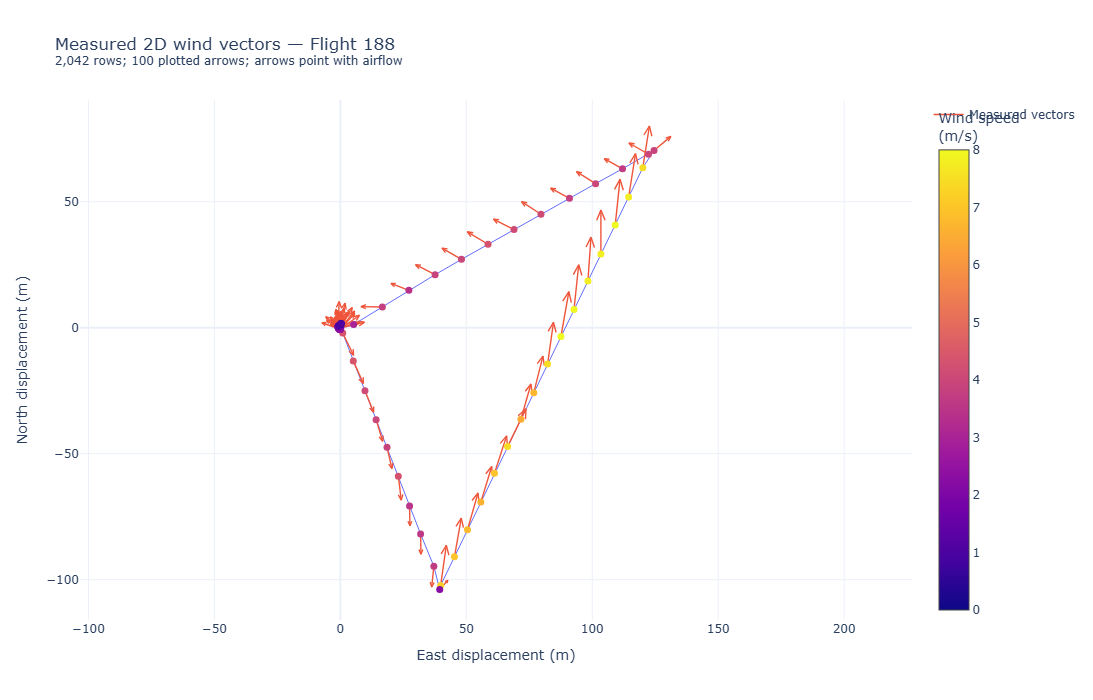

In [18]:
measured_fig = plot_measured_flight(
    original,
    flight_id=ORIGINAL_FLIGHT_ID,
    max_arrows=MAX_ARROWS,
)
measured_fig.show()


## 7. Compare measured and predicted wind on held-out test data


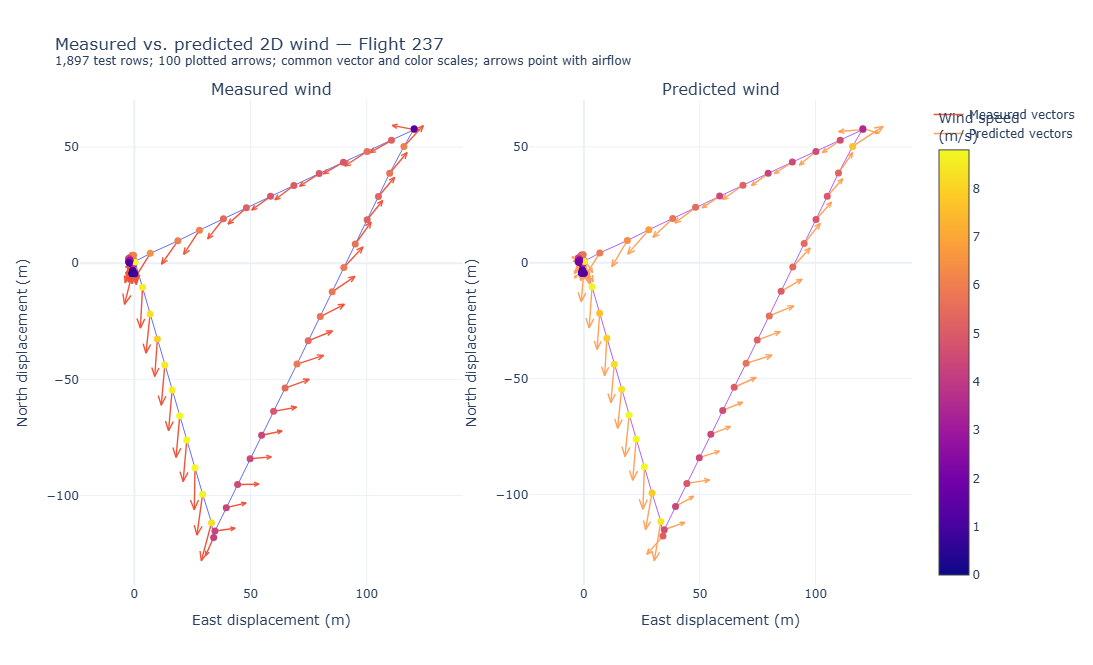

In [19]:
comparison_fig = plot_prediction_comparison(
    predictions,
    flight_id=COMPARISON_FLIGHT_ID,
    max_arrows=MAX_ARROWS,
)
comparison_fig.show()


## 8. Compare predictions along the flight sequence


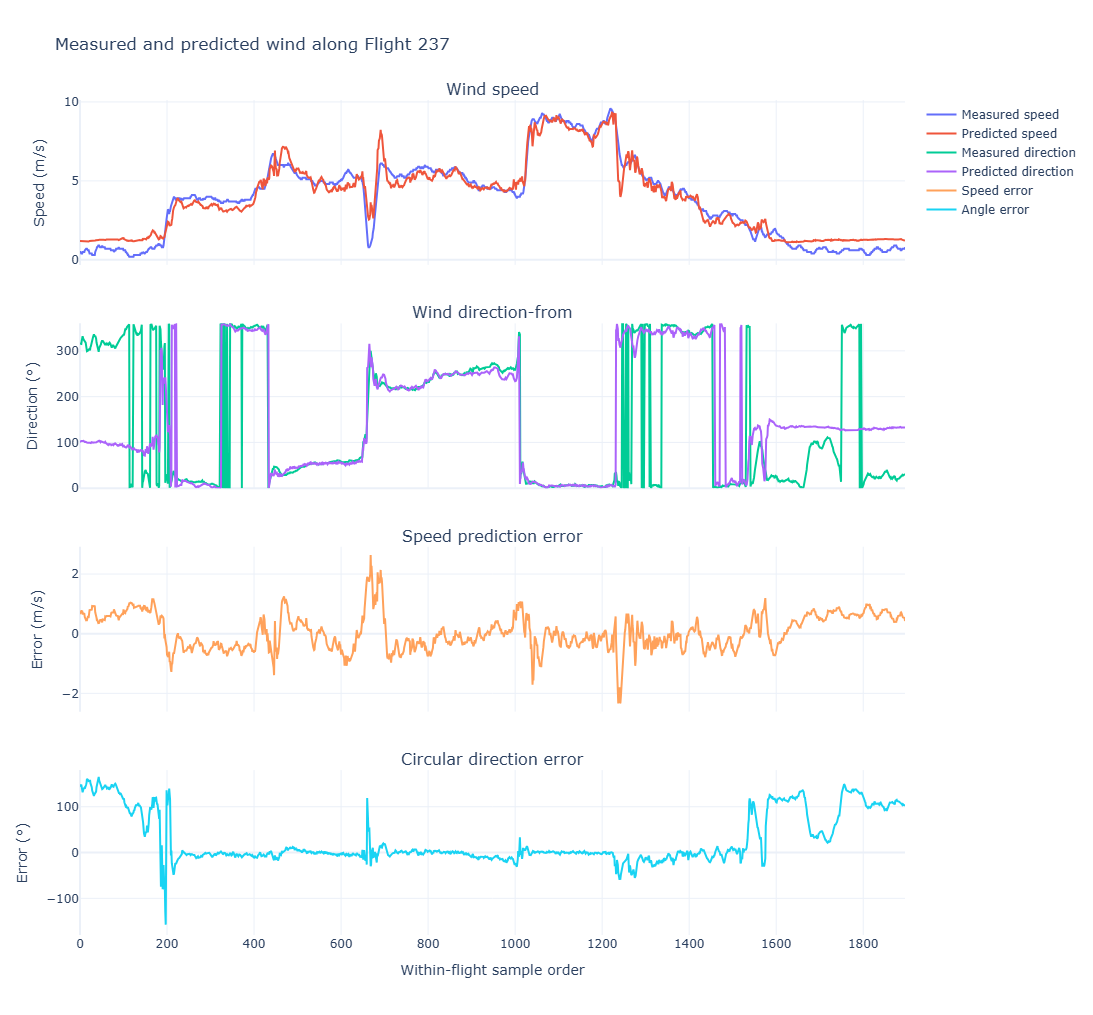

In [20]:
sequence_fig = plot_sequence_comparison(
    predictions,
    flight_id=COMPARISON_FLIGHT_ID,
)
sequence_fig.show()


## 9. Overall and per-flight prediction metrics


In [15]:
evaluation = predictions.copy()
evaluation["Computed_angle_error_deg"] = circular_difference_deg(
    evaluation["Predicted_wind_angle"],
    evaluation["Wind_angle"],
)
evaluation["Absolute_angle_error_deg"] = (
    evaluation["Computed_angle_error_deg"].abs()
)
evaluation["Speed_error_computed_mps"] = (
    evaluation["Predicted_wind_speed"] - evaluation["Wind_speed"]
)

direction_mask = evaluation["Wind_speed"] >= MIN_DIRECTION_SPEED_MPS

overall_metrics = pd.Series(
    {
        "Rows": len(evaluation),
        "Flights": evaluation["Flight_ID"].nunique(),
        "Speed MAE (m/s)": (
            evaluation["Speed_error_computed_mps"].abs().mean()
        ),
        "Speed RMSE (m/s)": np.sqrt(
            np.mean(evaluation["Speed_error_computed_mps"] ** 2)
        ),
        (
            f"Direction MAE (deg), speed >= "
            f"{MIN_DIRECTION_SPEED_MPS:g} m/s"
        ): evaluation.loc[
            direction_mask, "Absolute_angle_error_deg"
        ].mean(),
        (
            f"Direction RMSE (deg), speed >= "
            f"{MIN_DIRECTION_SPEED_MPS:g} m/s"
        ): np.sqrt(
            np.mean(
                evaluation.loc[
                    direction_mask, "Computed_angle_error_deg"
                ] ** 2
            )
        ),
    }
)
display(overall_metrics.to_frame("value"))

per_flight_metrics = (
    evaluation.assign(
        Absolute_speed_error_mps=(
            evaluation["Speed_error_computed_mps"].abs()
        ),
        Squared_speed_error=(
            evaluation["Speed_error_computed_mps"] ** 2
        ),
    )
    .groupby("Flight_ID")
    .agg(
        Rows=("Flight_ID", "size"),
        Mean_measured_speed_mps=("Wind_speed", "mean"),
        Speed_MAE_mps=("Absolute_speed_error_mps", "mean"),
        Speed_RMSE_mps=(
            "Squared_speed_error",
            lambda x: np.sqrt(x.mean()),
        ),
        Direction_MAE_deg=("Absolute_angle_error_deg", "mean"),
    )
    .sort_values("Speed_MAE_mps")
)
display(per_flight_metrics)


,value
Rows,54548.000000
Flights,42.000000
Speed MAE (m/s),0.626056
Speed RMSE (m/s),0.876185
"Direction MAE (deg), speed >= 0.5 m/s",27.758066
"Direction RMSE (deg), speed >= 0.5 m/s",45.166914


,Rows,Mean_measured_speed_mps,Speed_MAE_mps,Speed_RMSE_mps,Direction_MAE_deg
Flight_ID,,,,,
181,1172,4.609044,0.369681,0.480812,12.142540
97,1577,3.075777,0.427737,0.571391,39.768843
109,1691,4.537256,0.436865,0.610407,21.810964
145,1470,4.073061,0.445423,0.582931,14.743945
256,1150,4.153565,0.456829,0.619805,44.187352
173,1577,4.077108,0.466299,0.664591,40.920185
222,950,2.373263,0.466635,0.660146,32.603585
18,1135,5.064934,0.468486,0.645536,22.405391
221,809,2.688752,0.471485,0.589612,30.363226


## 10. Optional static Matplotlib figure

This is useful for reports or slides. It uses the same vector scale on both panels.


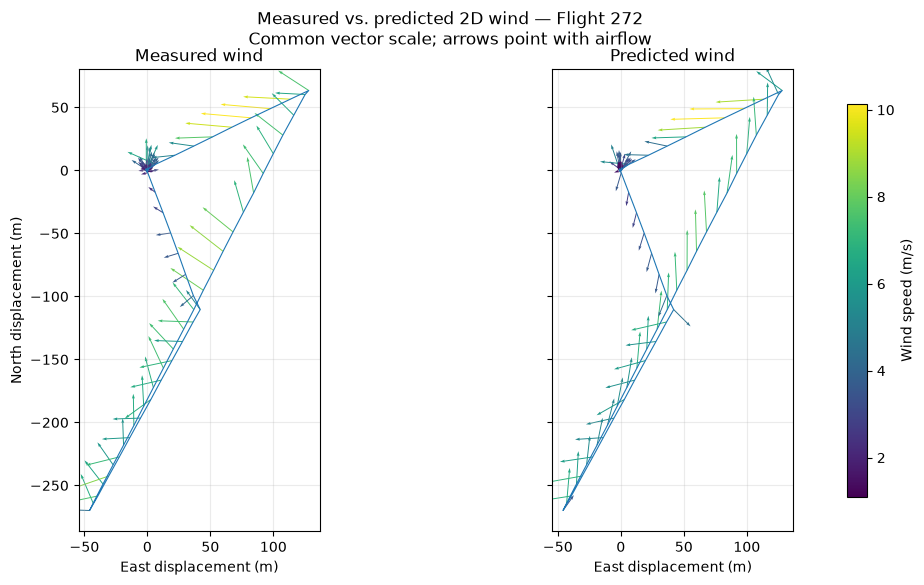

In [16]:
def plot_static_prediction_comparison(
    df: pd.DataFrame,
    flight_id,
    max_arrows: int = MAX_ARROWS,
):
    """Create a report-ready static measured-versus-predicted figure."""
    flight = df.loc[df["Flight_ID"] == flight_id].copy()
    if flight.empty:
        raise ValueError(f"Flight_ID {flight_id!r} is not present in predictions.")

    flight = flight.dropna(
        subset=[
            "X",
            "Y",
            "Wind_speed",
            "Wind_angle",
            "Predicted_wind_speed",
            "Predicted_wind_angle",
        ]
    )
    flight, _ = add_local_xy(flight)
    sampled = evenly_spaced_rows(flight, max_arrows)

    measured_east, measured_north = wind_components(
        sampled["Wind_speed"],
        sampled["Wind_angle"],
        DIRECTION_IS_FROM,
    )
    predicted_east, predicted_north = wind_components(
        sampled["Predicted_wind_speed"],
        sampled["Predicted_wind_angle"],
        DIRECTION_IS_FROM,
    )

    all_speeds = np.concatenate(
        [
            sampled["Wind_speed"].to_numpy(),
            sampled["Predicted_wind_speed"].to_numpy(),
        ]
    )
    vector_scale = robust_vector_scale(
        sampled["Plot_x_m"],
        sampled["Plot_y_m"],
        all_speeds,
    )

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(14, 6),
        sharex=True,
        sharey=True,
    )

    panels = [
        (
            axes[0],
            measured_east,
            measured_north,
            sampled["Wind_speed"],
            "Measured wind",
        ),
        (
            axes[1],
            predicted_east,
            predicted_north,
            sampled["Predicted_wind_speed"],
            "Predicted wind",
        ),
    ]

    quivers = []
    for ax, east, north, speeds, title in panels:
        ax.plot(
            sampled["Plot_x_m"],
            sampled["Plot_y_m"],
            linewidth=0.8,
        )
        quiver = ax.quiver(
            sampled["Plot_x_m"],
            sampled["Plot_y_m"],
            east * vector_scale,
            north * vector_scale,
            speeds,
            angles="xy",
            scale_units="xy",
            scale=1,
            width=0.004,
        )
        quivers.append(quiver)
        ax.set_title(title)
        ax.set_xlabel("East displacement (m)")
        ax.set_aspect("equal", adjustable="box")
        ax.grid(alpha=0.25)

    axes[0].set_ylabel("North displacement (m)")
    fig.colorbar(
        quivers[-1],
        ax=axes,
        label="Wind speed (m/s)",
        shrink=0.85,
    )
    fig.suptitle(
        f"Measured vs. predicted 2D wind — Flight {flight_id}\n"
        "Common vector scale; arrows point with airflow"
    )
    return fig


static_fig = plot_static_prediction_comparison(
    predictions,
    flight_id=COMPARISON_FLIGHT_ID,
)
plt.show()


## 11. Export interactive or static results


In [ ]:
OUTPUT_DIR = Path("wind_visualization_output")
OUTPUT_DIR.mkdir(exist_ok=True)

comparison_html = (
    OUTPUT_DIR
    / f"wind_comparison_flight_{COMPARISON_FLIGHT_ID}.html"
)
sequence_html = (
    OUTPUT_DIR
    / f"wind_sequence_flight_{COMPARISON_FLIGHT_ID}.html"
)

comparison_fig.write_html(comparison_html, include_plotlyjs="cdn")
sequence_fig.write_html(sequence_html, include_plotlyjs="cdn")

static_png = (
    OUTPUT_DIR
    / f"wind_comparison_flight_{COMPARISON_FLIGHT_ID}.png"
)
static_fig.savefig(static_png, dpi=200, bbox_inches="tight")

print("Saved:")
print(" -", comparison_html.resolve())
print(" -", sequence_html.resolve())
print(" -", static_png.resolve())

# Plotly PNG export is also possible after installing Kaleido:
# %pip install kaleido
# comparison_fig.write_image(
#     OUTPUT_DIR
#     / f"wind_comparison_flight_{COMPARISON_FLIGHT_ID}_plotly.png",
#     scale=2,
# )


## Notes for interpretation

- The arrows show horizontal wind only. `Z` is displayed in hover text but is not used as a third spatial dimension.
- Both panels in the prediction comparison use the same sampled rows, arrow multiplier, axis aspect ratio, and speed color range.
- Direction errors are circular: a prediction of \(1^\circ\) versus an actual value of \(359^\circ\) is a \(2^\circ\) error, not \(358^\circ\).
- Wind direction is unreliable when speed is close to zero, so the direction-error summary excludes measured speeds below `MIN_DIRECTION_SPEED_MPS`.
- The CSV timestamps are too coarse to order samples within a flight. The notebook preserves the original row ordering, matching the model artifact's requirement that feature generation retain within-flight chronological order.
